Analyse Exploratoire 

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import cv2
from collections import Counter
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Chemins des données nettoyées (après preprocessing)
OCT_PATH  = "../data/OCT_aug"
XRAY_PATH = "../data/xray_aug"

SPLITS = ['train', 'val', 'test']

 Distribution par classes (toutes les splits)

In [4]:
def compter_distribution(base_path, dataset_name):
    data = {}
    for split in SPLITS:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            continue
        data[split] = {}
        for classe in sorted(os.listdir(split_path)):
            classe_path = os.path.join(split_path, classe)
            if os.path.isdir(classe_path):
                data[split][classe] = len(os.listdir(classe_path))
    
    # Affichage texte
    print(f"\n{'='*50}")
    print(f"  {dataset_name} — Distribution par split")
    print(f"{'='*50}")
    for split, classes in data.items():
        total = sum(classes.values())
        print(f"\n{split.upper()} (total={total}) :")
        for classe, nb in classes.items():
            pct = nb / total * 100
            print(f"  {classe:12} : {nb:6} images ({pct:.1f}%)")
    
    return data

oct_dist  = compter_distribution(OCT_PATH,  "OCT")
xray_dist = compter_distribution(XRAY_PATH, "X-RAY")


  OCT — Distribution par split

TRAIN (total=128393) :
  CNV          :  32280 images (25.1%)
  DME          :  32280 images (25.1%)
  DRUSEN       :  32280 images (25.1%)
  NORMAL       :  31553 images (24.6%)

VAL (total=9229) :
  CNV          :   3798 images (41.2%)
  DME          :   1335 images (14.5%)
  DRUSEN       :    941 images (10.2%)
  NORMAL       :   3155 images (34.2%)

TEST (total=15373) :
  CNV          :   6330 images (41.2%)
  DME          :   2219 images (14.4%)
  DRUSEN       :   1568 images (10.2%)
  NORMAL       :   5256 images (34.2%)

  X-RAY — Distribution par split

TRAIN (total=8658) :
  NORMAL       :   4329 images (50.0%)
  PNEUMONIA    :   4329 images (50.0%)

VAL (total=699) :
  NORMAL       :    189 images (27.0%)
  PNEUMONIA    :    510 images (73.0%)

TEST (total=1165) :
  NORMAL       :    316 images (27.1%)
  PNEUMONIA    :    849 images (72.9%)


Visualisation barplots distribution

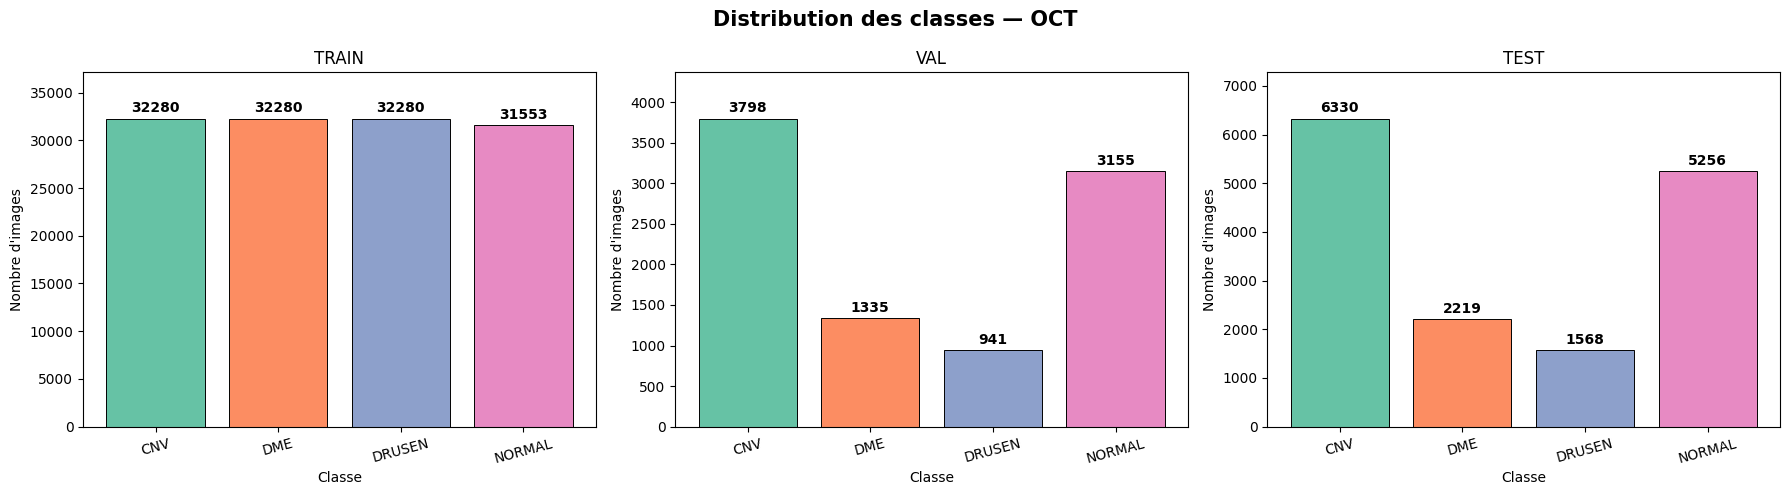

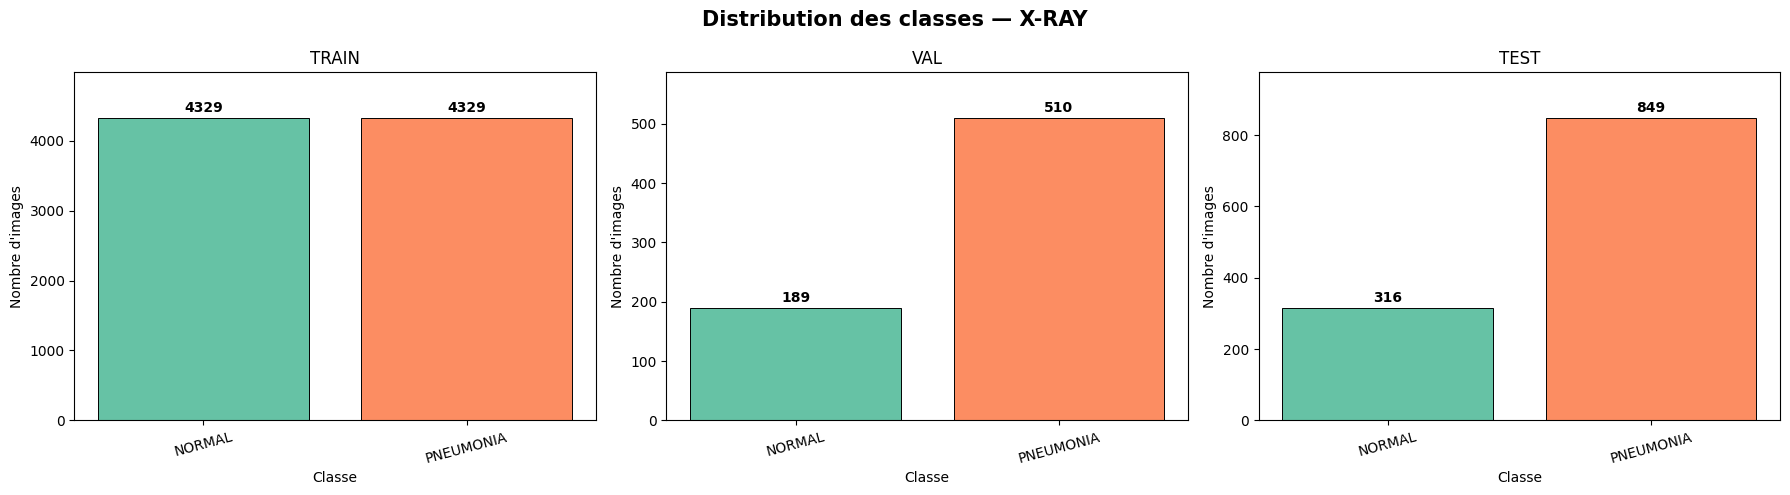

In [7]:
def plot_distribution(dist_data, dataset_name):
    n_splits = len(dist_data)
    fig, axes = plt.subplots(1, n_splits, figsize=(6 * n_splits, 5))
    fig.suptitle(f"Distribution des classes — {dataset_name}", fontsize=15, fontweight='bold')

    if n_splits == 1:
        axes = [axes]

    colors = plt.cm.Set2.colors

    for ax, (split, classes) in zip(axes, dist_data.items()):
        noms   = list(classes.keys())
        valeurs = list(classes.values())
        bars   = ax.bar(noms, valeurs, color=colors[:len(noms)], edgecolor='black', linewidth=0.7)
        
        for bar, val in zip(bars, valeurs):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(valeurs)*0.01,
                    str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        ax.set_title(split.upper(), fontsize=12)
        ax.set_xlabel("Classe")
        ax.set_ylabel("Nombre d'images")
        ax.tick_params(axis='x', rotation=15)
        ax.set_ylim(0, max(valeurs) * 1.15)

    plt.tight_layout()
    plt.savefig(f"../EDA/eda_distribution_{dataset_name}.png", dpi=150)
    plt.show()

plot_distribution(oct_dist,  "OCT")
plot_distribution(xray_dist, "X-RAY")

Analyse de la luminosité par classe


  OCT (train) — Statistiques luminosité
       moyenne                                                      std  \
         count   mean    std    min    25%    50%    75%     max  count   
classe                                                                    
CNV      300.0  56.69  22.77  20.46  40.76  49.90  69.98  150.07  300.0   
DME      300.0  46.88  18.23  19.15  33.16  42.28  55.36  109.13  300.0   
DRUSEN   300.0  53.14  22.38  23.28  39.34  47.20  59.68  165.64  300.0   
NORMAL   300.0  47.69  18.00  22.99  36.21  43.05  53.56  167.08  300.0   

               ...                contraste                              \
         mean  ...    75%     max     count    mean   std    min    25%   
classe         ...                                                        
CNV     52.73  ...  62.74  104.89     300.0  255.00  0.00  255.0  255.0   
DME     48.75  ...  59.36   98.28     300.0  254.97  0.47  247.0  255.0   
DRUSEN  54.83  ...  64.98  105.34     300.0  255.00  0.00 

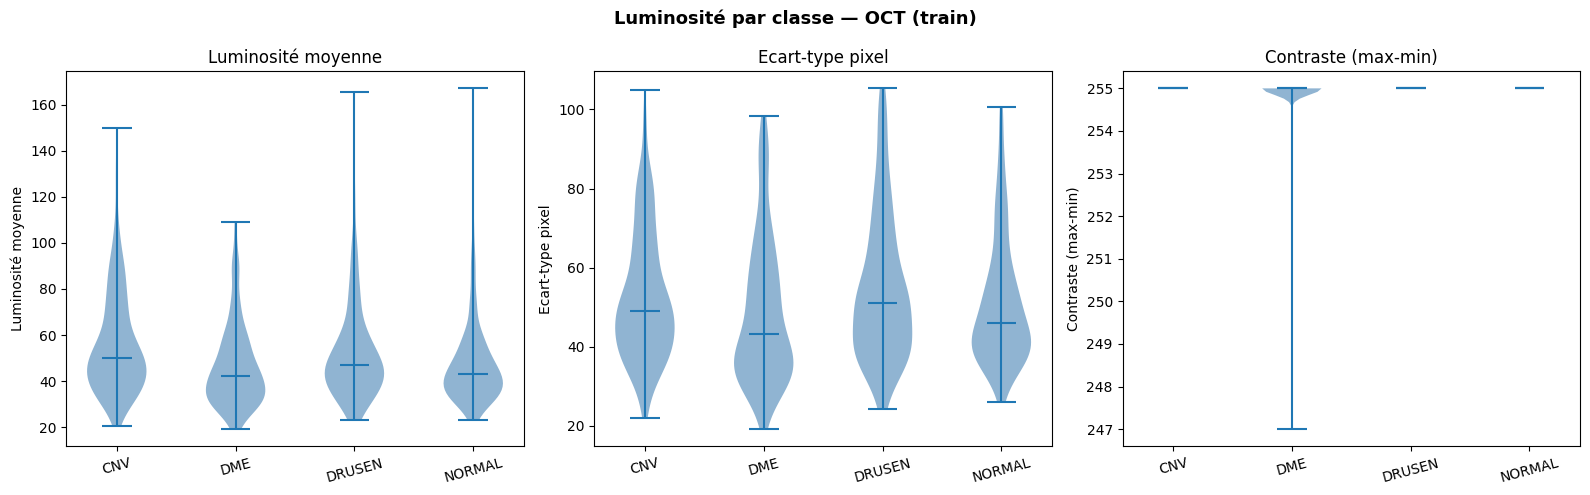


  X-RAY (train) — Statistiques luminosité
          moyenne                                                        \
            count    mean    std    min     25%     50%     75%     max   
classe                                                                    
NORMAL      300.0  122.58  12.83  86.49  114.56  122.81  130.93  159.59   
PNEUMONIA   300.0  125.31  19.30  72.58  111.56  125.32  138.04  175.37   

             std         ...              contraste                        \
           count   mean  ...    75%   max     count    mean    std    min   
classe                   ...                                                
NORMAL     300.0  61.10  ...  64.79  83.1     300.0  254.94   0.83  242.0   
PNEUMONIA  300.0  57.77  ...  64.52  87.4     300.0  247.45  16.22  176.0   

                                       
             25%    50%    75%    max  
classe                                 
NORMAL     255.0  255.0  255.0  255.0  
PNEUMONIA  247.0  255.0  255.0  255

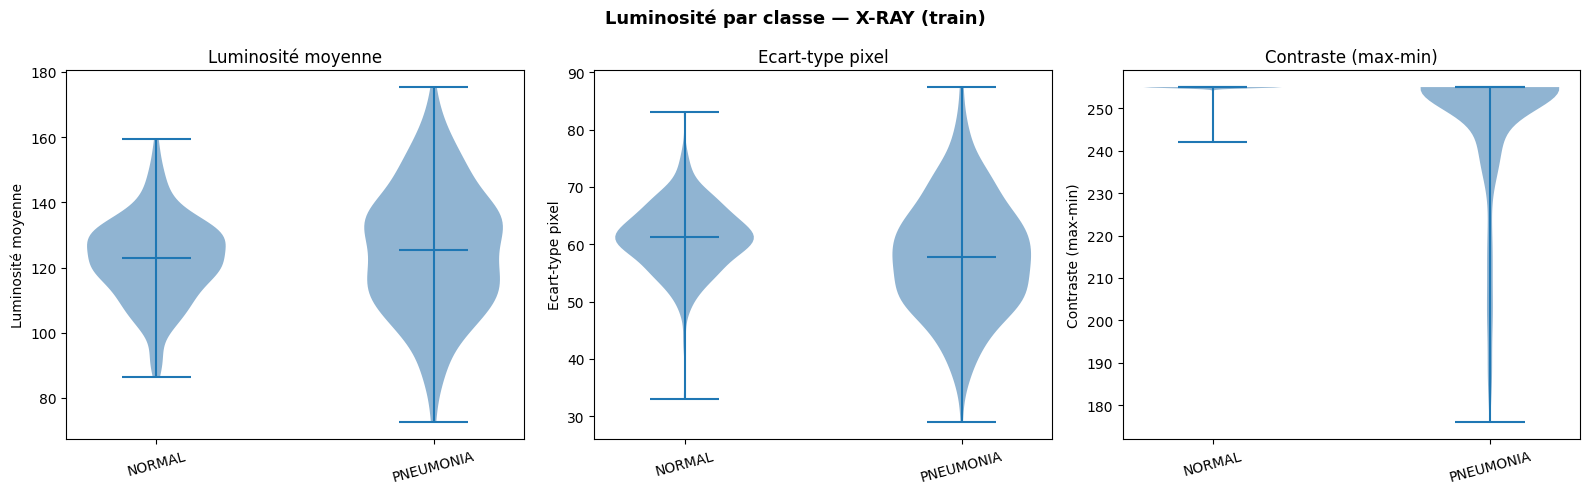

In [12]:
def analyser_luminosite(base_path, split, dataset_name, max_par_classe=300):
    split_path = os.path.join(base_path, split)
    records    = []

    for classe in sorted(os.listdir(split_path)):
        classe_path = os.path.join(split_path, classe)
        if not os.path.isdir(classe_path):
            continue
        for img_file in sorted(os.listdir(classe_path))[:max_par_classe]:
            img_path = os.path.join(classe_path, img_file)
            try:
                img = np.array(Image.open(img_path).convert('L'))
                records.append({
                    'classe'     : classe,
                    'moyenne'    : round(img.mean(), 2),
                    'std'        : round(img.std(),  2),
                    'min_pixel'  : int(img.min()),
                    'max_pixel'  : int(img.max()),
                    'contraste'  : round(img.max() - img.min(), 2)
                })
            except:
                pass

    df = pd.DataFrame(records)

    print(f"\n{'='*50}")
    print(f"  {dataset_name} ({split}) — Statistiques luminosité")
    print(f"{'='*50}")
    print(df.groupby('classe')[['moyenne','std','contraste']].describe().round(2))

    # Violin plots
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"Luminosité par classe — {dataset_name} ({split})", fontsize=13, fontweight='bold')

    for ax, col, titre in zip(axes,
                               ['moyenne', 'std', 'contraste'],
                               ['Luminosité moyenne', 'Ecart-type pixel', 'Contraste (max-min)']):
        classes_list = df['classe'].unique()
        data_by_class = [df[df['classe'] == c][col].values for c in sorted(classes_list)]
        
        vp = ax.violinplot(data_by_class, showmedians=True)
        for pc in vp['bodies']:
            pc.set_facecolor('steelblue')
            pc.set_alpha(0.6)
        
        ax.set_xticks(range(1, len(classes_list) + 1))
        ax.set_xticklabels(sorted(classes_list), rotation=15)
        ax.set_title(titre)
        ax.set_ylabel(titre)

    plt.tight_layout()
    plt.savefig(f"../EDA/eda_luminosite_{dataset_name}.png", dpi=150)
    plt.show()

    return df

df_oct_lum  = analyser_luminosite(OCT_PATH,  "train", "OCT")
df_xray_lum = analyser_luminosite(XRAY_PATH, "train", "X-RAY")

Histogrammes de pixels moyens par classe

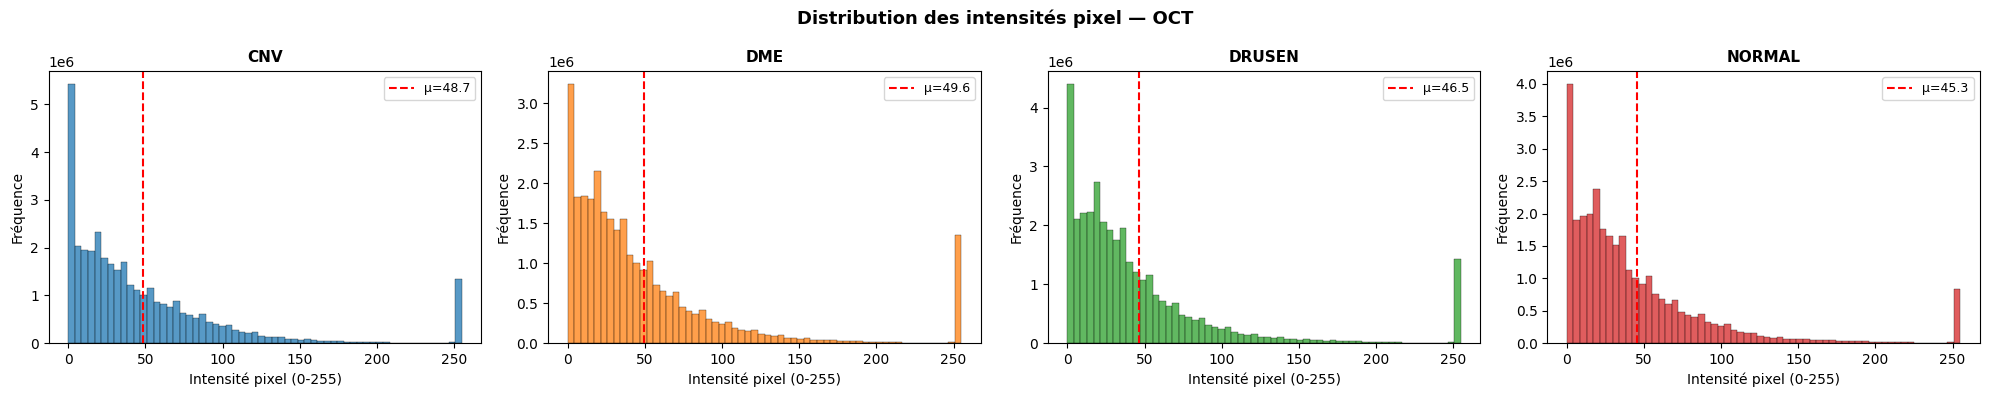

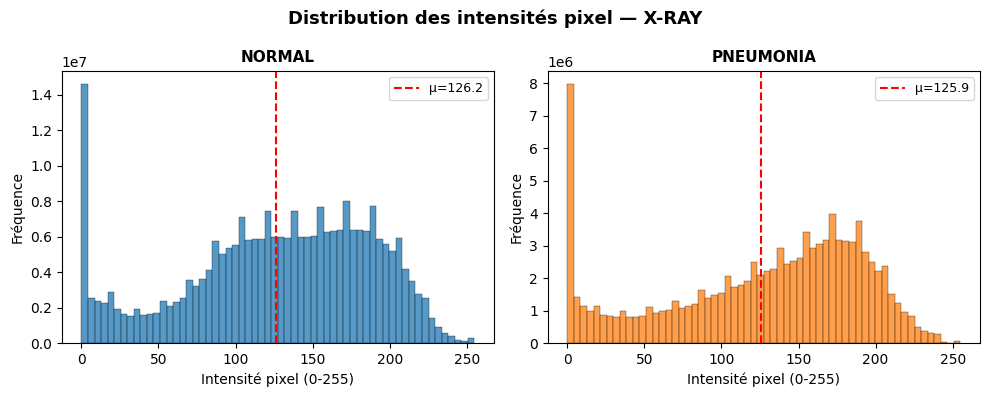

In [14]:
def plot_histogrammes_pixels(base_path, split, dataset_name, max_par_classe=100):
    split_path = os.path.join(base_path, split)
    classes    = sorted([c for c in os.listdir(split_path)
                         if os.path.isdir(os.path.join(split_path, c))])

    fig, axes = plt.subplots(1, len(classes), figsize=(5 * len(classes), 4))
    fig.suptitle(f"Distribution des intensités pixel — {dataset_name}",
                 fontsize=13, fontweight='bold')

    if len(classes) == 1:
        axes = [axes]

    colors = plt.cm.tab10.colors

    for ax, classe, color in zip(axes, classes, colors):
        classe_path  = os.path.join(split_path, classe)
        all_pixels   = []

        for img_file in sorted(os.listdir(classe_path))[:max_par_classe]:
            img  = np.array(Image.open(os.path.join(classe_path, img_file)).convert('L'))
            all_pixels.extend(img.flatten().tolist())

        all_pixels = np.array(all_pixels)
        ax.hist(all_pixels, bins=60, color=color, alpha=0.75, edgecolor='black', linewidth=0.3)
        ax.axvline(all_pixels.mean(), color='red', linestyle='--', linewidth=1.5,
                   label=f"μ={all_pixels.mean():.1f}")
        ax.set_title(classe, fontsize=11, fontweight='bold')
        ax.set_xlabel("Intensité pixel (0-255)")
        ax.set_ylabel("Fréquence")
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f"../EDA/eda_histogrammes_{dataset_name}.png", dpi=150)
    plt.show()

plot_histogrammes_pixels(OCT_PATH,  "train", "OCT")
plot_histogrammes_pixels(XRAY_PATH, "train", "X-RAY")

Corrélation luminosité / taille (scatter)

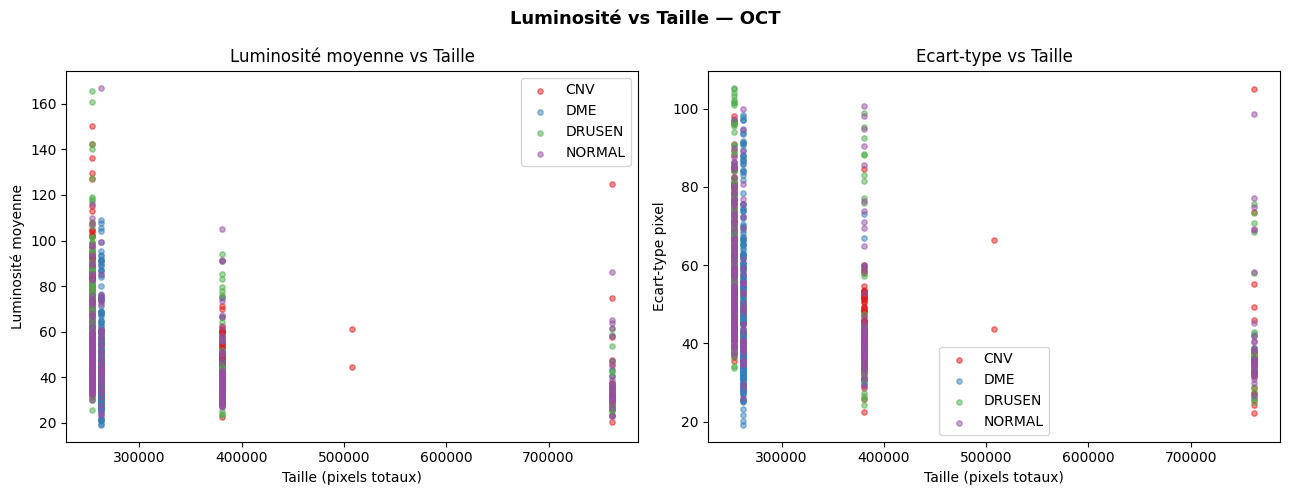

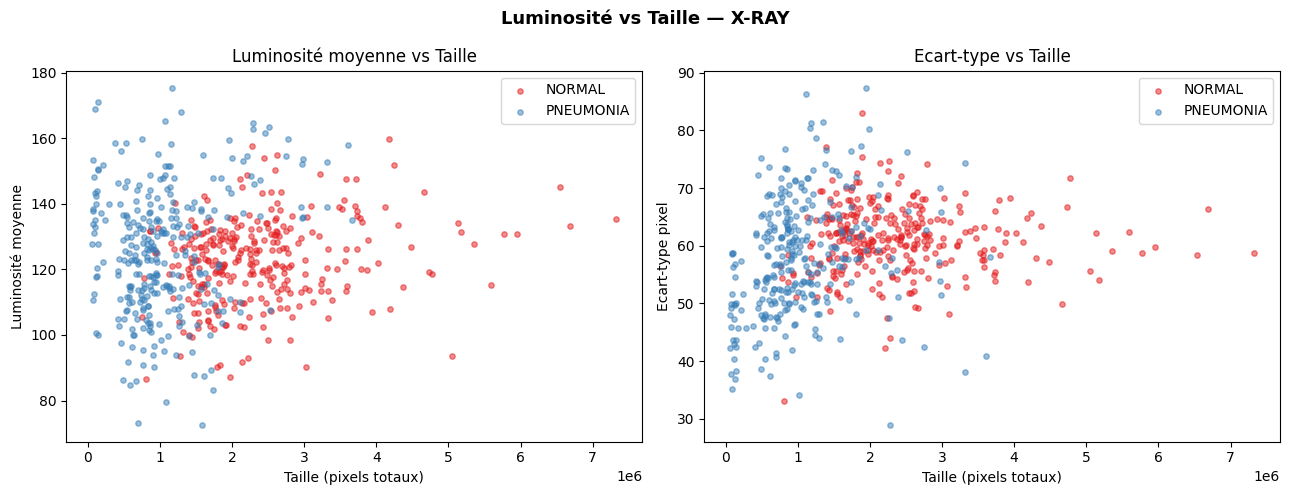

In [16]:
def plot_luminosite_vs_taille(df_lum, df_sizes, dataset_name):
    df = pd.merge(
        df_lum[['classe','moyenne','std']],
        df_sizes[['classe','pixels']],
        left_index=True, right_index=True,
        suffixes=('_lum','_size')
    )

    classes     = df['classe_lum'].unique()
    colors_map  = {c: plt.cm.Set1.colors[i] for i, c in enumerate(sorted(classes))}

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"Luminosité vs Taille — {dataset_name}",
                 fontsize=13, fontweight='bold')

    for classe in sorted(classes):
        sub = df[df['classe_lum'] == classe]
        c   = colors_map[classe]

        axes[0].scatter(sub['pixels'], sub['moyenne'],
                        label=classe, alpha=0.5, s=15, color=c)
        axes[1].scatter(sub['pixels'], sub['std'],
                        label=classe, alpha=0.5, s=15, color=c)

    axes[0].set_xlabel("Taille (pixels totaux)")
    axes[0].set_ylabel("Luminosité moyenne")
    axes[0].set_title("Luminosité moyenne vs Taille")
    axes[0].legend()

    axes[1].set_xlabel("Taille (pixels totaux)")
    axes[1].set_ylabel("Ecart-type pixel")
    axes[1].set_title("Ecart-type vs Taille")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"../EDA/eda_scatter_{dataset_name}.png", dpi=150)
    plt.show()

plot_luminosite_vs_taille(df_oct_lum,  df_oct_sizes,  "OCT")
plot_luminosite_vs_taille(df_xray_lum, df_xray_sizes, "X-RAY")